In [121]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [122]:
sns.set_style("whitegrid")
params_grid = {"color": 'lightgrey', "linestyle": 'dotted', "linewidth": 0.7 }

# Jeu de cartes red-black

On dispose d’un jeu de $N$ cartes composé d'autant de cartes rouges que de cartes noires. Le joueur part d’une fortune initiale nulle, $Z_0 = 0$, et à l’étape $n \in \{1, \dots, N\}$ il tire une carte et gagne $+1$ si la carte est noire ou perd 1 (gagne $-1$) si la carte est rouge.  
La carte est alors retirée du jeu et le joueur décide de continuer le jeu ou de quitter le jeu avec sa fortune actuelle.  

- Faut-il jouer à ce jeu ? 
- Si oui combien est-on prêt à payer pour jouer à ce jeu, quelle est la valeur de ce jeu ?
- Comment jouer *au mieux* à ce jeu ? 

## Modélisation

On modélise le jeu de la façon suivante. Soit $(X_n)_{n \in \{0,\dots,N\}}$ la chaîne de Markov qui représente le nombre de cartes noires tirées depuis le début du jeu. Pour $n$ fixé, $X_n$ est à valeurs dans $E_n \subset E = \{0, \dots, N/2 \}$. Les transitions $(P_n)_{n = 1,\dots,N}$ de la CM sont définies par $P_{n}(x, y) = \mathbf{P} \big(X_n = y | X_{n-1} = x\big)$ et vérifient 
\begin{equation*}
\forall x, y \in E, \quad 
P_n(x, y) = \begin{cases}
\frac{N/2 - x}{N - (n-1)} & \text{si } y = x+1, \\
\frac{N/2 - (n-x)}{N - (n-1)} & \text{si } y = x, \\ 
0 & \text{sinon} \\
\end{cases}
\end{equation*}

Les fonctions de gains ou payoffs $\varphi$ sont données par $\varphi_n(x) = 2x-n$.

In [123]:
N = 8         # nombres de cartes
Nb = N // 2     # nombres de cartes black

In [124]:
# states[n]: les valeurs possibles en n: le nombre de cartes noires tirées depuis le début du jeu
# P[n]: matrice de transition de la chaine de Markov 

states, P = [ None ] * (N+1), [ None ] * (N+1)
states[0] = np.array([ 0 ])
for n in range(1, N+1): 
    states[n] = np.arange(max(0, n-Nb), min(n, Nb)+1)
    P[n] = np.zeros((len(states[n-1]), len(states[n]))) 
    for i, x in enumerate(states[n-1]):
        for j, y in enumerate(states[n]):
            if (y == x): P[n][i,j] = (Nb-((n-1)-x)) / (N-(n-1))
            if (y == x+1): P[n][i,j] = (Nb-x) / (N-(n-1)) 

In [125]:
# Z_n = phi_n(X_n) avec phi_n(x) = 2x - n
payoffs = []
for n, xn in enumerate(states):
    payoffs.append(2*xn - n)

In [126]:
P[2]

array([[0.42857143, 0.57142857, 0.        ],
       [0.        , 0.57142857, 0.42857143]])

## Construction des fonctions valeurs $V_n$

Les fonctions valeurs vérifient le système rétrograde 
$$
    \begin{cases}
        V_N(x) = \phi_N(x) & \forall x \in E_N, \\
        V_n(x) = \max\big(\phi_n(x), P_{n+1} V_{n+1}(x) \big) & \forall x \in E_n, \quad n = 0, \dots, N-1
    \end{cases}
$$

**Remarque**: $S_n = V_n(X_n)$ représente la valeur de jeu (du produit) à l'itération $n$ lorsque le système est dans l'état $X_n$. Le prix en zéro est donc $S_0 = V_0(x_0)$. 

In [127]:
V = [ None ] * (N+1)
V[N] = payoffs[N]
for n in reversed(range(N)):
    # l'algorithme codé directement en matriciel: 
    # payoffs[n] correspond à Z_n
    # P[n] @ V[n+1] correspond à l'espérance conditionnelle E[S_{n+1} | F_n] où S_n = V_n(X_n)
    V[n] = np.maximum(payoffs[n], P[n+1] @ V[n+1]) # récurrence rétrograde sur la fonction valeur

In [128]:
def make_regions(payoffs, V): 
    N = len(V)-1
    # on définit la région d'arrêt: 0 continuation et 1 arrêt 
    regions = [ np.isclose(payoffs[n], V[n]).astype('int') for n in range(N+1) ]
    
    for n in range(N):
        # pour chaque état de $E_{n+1}$ on met la valeur à -1 s'il est dans la rétion d'arrêt
        # mais non accessible à partir d'un état de $E_n$.
        for j, y in enumerate(states[n+1]):
            to_visited = False
            for i, x in enumerate(states[n]):
                if ((P[n+1][i,j] > 0) and regions[n][i] == 0): 
                    to_visited = True
                    break
            if (not to_visited and regions[n+1][j] == 1):
                regions[n+1][j] = -1
    return regions

## Affichage des fonctions valeurs 

In [129]:
from matplotlib.patches import Patch

In [130]:
def plot(ax, data, color=True):
    regions = make_regions(payoffs, V)
    size = 60 * 8 / N # if N <= 10 else 6
    ax.grid(color='lightgrey', linestyle='dotted', linewidth=0.7)
    if color: 
        colors = {1: 'red', 0: 'green', -1:'lightgrey'}
    else:
        colors = {1: 'lightgrey', 0: 'lightgrey', -1:'lightgrey'} 
    for n in range(N+1):
        for v, z, s in zip(V[n], data[n], regions[n]):
            ax.scatter(n, z, color=colors[s], marker='o', s=size)
            if (N <= 10 or n == 0): 
                ax.annotate(f'{v:.1f}', xy = (n, z), xytext = (0, 12),
                            textcoords = 'offset points', ha = 'center', va = 'center',
                            bbox = dict(boxstyle = 'round,pad=0.2', fc = colors[s], alpha = 0.3))
    if color: 
        legend_elements = [
            Patch(facecolor=colors[0], label='Continuation region'),
            Patch(facecolor=colors[1], label='Free boundary'),
            Patch(facecolor=colors[-1], label='Inaccessible region'),
        ]
        ax.legend(handles=legend_elements)
    return ax

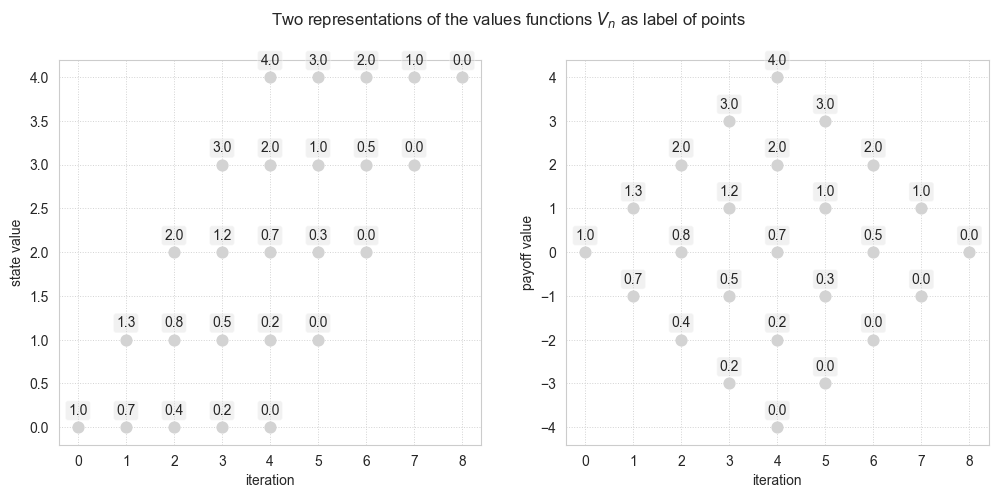

In [131]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
plot(ax1, states, color=False)
ax1.set_ylabel("state value")
plot(ax2, payoffs, color=False)
ax2.set_ylabel("payoff value")
for ax in (ax1, ax2):
    ax.set_xlabel("iteration")
fig.suptitle("Two representations of the values functions $V_n$ as label of points")
plt.show()

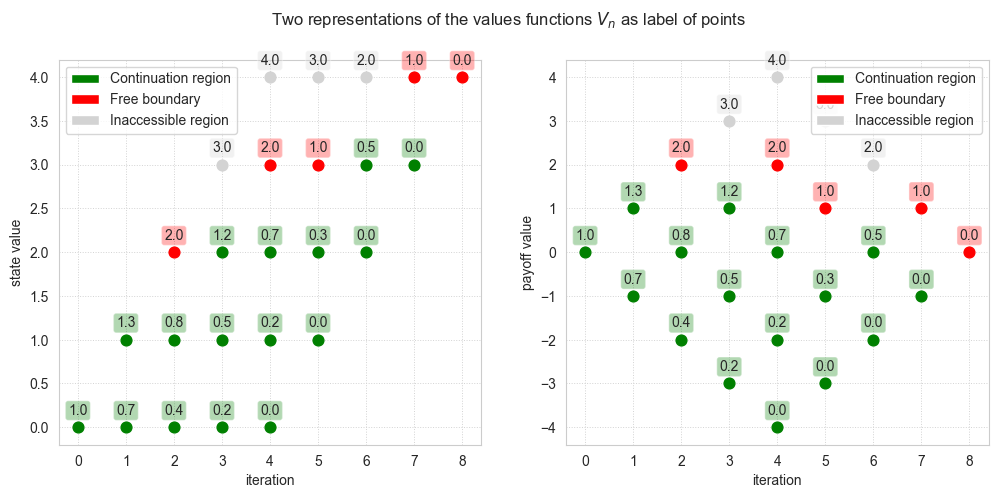

In [132]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
plot(ax1, states)
ax1.set_ylabel("state value")
plot(ax2, payoffs)
ax2.set_ylabel("payoff value")
for ax in (ax1, ax2):
    ax.set_xlabel("iteration")
fig.suptitle("Two representations of the values functions $V_n$ as label of points")
plt.show()

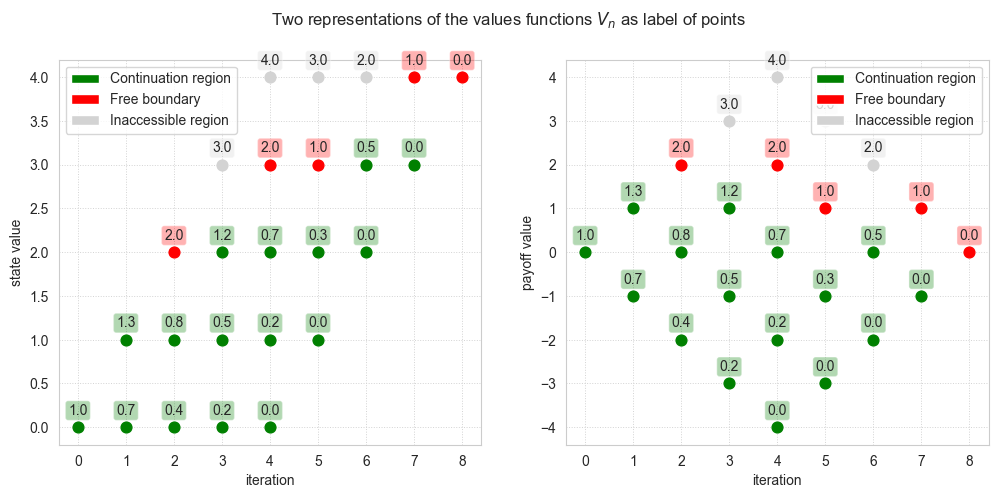

In [133]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
plot(ax1, states)
ax1.set_ylabel("state value")
plot(ax2, payoffs)
ax2.set_ylabel("payoff value")
for ax in (ax1, ax2):
    ax.set_xlabel("iteration")
fig.suptitle("Two representations of the values functions $V_n$ as label of points")
plt.show()

## Valeur du jeu en 0 (prix en 0)

In [ ]:
print(V[0])
# ici tous les calculs sont exactes car on sait calculer 
# P_n V_{n+1} par un produit matrice-vecteur
print(V[1])
print(V[2])
print(V[3] )

[1.]
[0.65714286 1.34285714]
[0.4  0.85 2.  ]
[0.2 0.5 1.2 3. ]


## Réprésentation graphique d'un scénario

In [135]:
regions = make_regions(payoffs, V)

In [136]:
path = np.zeros(N+1, dtype=int)
#path = np.array([0,1,2,3,3,2,1,1,0], dtype=int)
for n in range(1, N+1): 
    path[n] = np.random.choice(np.arange(P[n].shape[1]), 1, p=P[n][path[n-1]])[0]
    if (regions[n][path[n]] == 1): break # on sort et la valeur n est figée 
    
# le morceau de trajectoire qui nous intéresse est jusqu'en n  
gains = np.array([payoffs[k][path[k]] for k in range(n+1)])
print(f"Les gains depuis le début du jeu sont: {gains}.")
# et la valeur de sortie de cette trajectoire
print(f"On quitte le jeu après le tirage {n} avec le gain {payoffs[n][path[n]]}.")

Les gains depuis le début du jeu sont: [ 0  1  0 -1 -2 -1 -2 -1  0].
On quitte le jeu après le tirage 8 avec le gain 0.


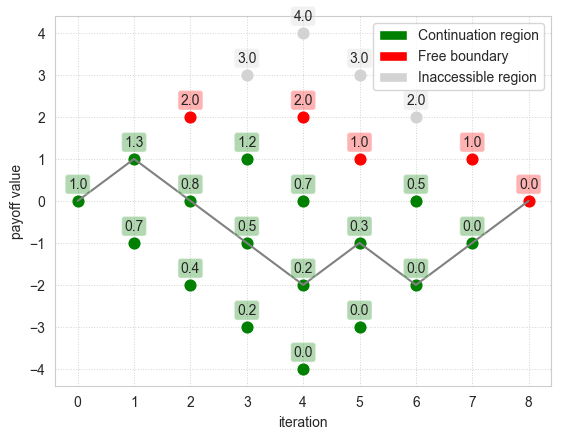

In [137]:
fig, ax = plt.subplots()
plot(ax, payoffs)
ax.set_ylabel("payoff value")
ax.set_xlabel("iteration")
ax.plot(np.arange(n+1), gains, lw=1.5, color='grey')
plt.show()

## Moyennisation sur M scénarios

In [138]:
regions = make_regions(payoffs, V)
M = int(1e4)
gains_opt = np.zeros(M)
path = np.zeros(N+1, dtype=int)
for j in range(M):
    for n in range(1, N+1): 
        path[n] = np.random.choice(np.arange(P[n].shape[1]), 1, p=P[n][path[n-1]])[0]
        if (regions[n][path[n]] == 1): break # on sort et la valeur n est figée 
    gains_opt[j] = payoffs[n][path[n]]  

# V_0 = E[Z_\tau^*] 
m = np.mean(gains_opt)
ic_size = 1.96 * np.sqrt(np.var(gains_opt, ddof=1) / M) 
print(f"La valeur de l'estimateur avec {M} tirages est: {m:.4}, et la variance estimée est {np.var(gains_opt):.4}.")
print(f"La vraie valeur se trouve dans l'intervalle [{m-ic_size:.4}, {m+ic_size:.4}] avec proba 0.95 (M = {M}).")
print(f"La vraie valeur est: {V[0][0]:.4}")

La valeur de l'estimateur avec 10000 tirages est: 0.9999, et la variance estimée est 0.6607.
La vraie valeur se trouve dans l'intervalle [0.984, 1.016] avec proba 0.95 (M = 10000).
La vraie valeur est: 1.0


# Put américain dans le modèle binomial 

## Modélisation

On se propose de valoriser une option put américaine dans un cadre Cox-Ross-Rubinstein (CRR).

On note $r$ le taux d'actualisation continu et $T$ la maturité de l'option. On discrétise le temps en des instants $t_n = n \frac{T}{N}$.
À chaque date $t_n$ le détenteur de l'option peut choisir d'exercer l'option (option américaine). 

On note $V_n(X_n)$ la valeur du put et $X_n$ le prix sous-jacent à la date $t_n$. On cherche
$$
    V_0(X_0) = \sup_{\tau \in \mathcal{T}_0^N} \mathbb{E}[Z_\tau]
$$
avec $Z_n = \varphi_n(X_n) = e^{-rt_n}(K - X_n)_+$ le payoff (d'un Put) actualisé de l'option et $\mathcal{T}_n^N$ l'ensemble des temps d'arrêts entre $n$ et $N$.

In [139]:
r, sigma = 0.10, 0.25 
S0 = 100.
T, N = 1, 8

dt = T / N
up = math.exp(sigma * math.sqrt(dt))
down = 1. / up
p = 0.5 * (1 + (r-0.5*sigma**2) * math.sqrt(dt) / sigma)
print(p)

0.5486135912065752


In [140]:
# states[n]: les valeurs possibles en n
# P[n]: matrice de transition de la chaine de Markov 

states, P = [ None ] * (N+1), [ None ] * (N+1)
states[0] = np.array([ S0 ])
for n in range(1, N+1): 
    states[n] = np.array([ S0 * up**n_up * down**(n-n_up) for n_up in range(n+1) ])
    P[n] = np.zeros((len(states[n-1]), len(states[n])))    # refaire avec une matrice creuse.. 
    for i, x in enumerate(states[n-1]):
        for j, y in enumerate(states[n]):
            if math.isclose(y, x*up): P[n][i,j] = p
            if math.isclose(y, x*down): P[n][i,j] = 1-p

In [141]:
K = 110.
payoffs = []
for n, xn in enumerate(states):
    payoffs.append(math.exp(-r * n*dt) * np.maximum((K - xn), 0))

## Fonctions valeurs 

In [142]:
V = [ None ] * (N+1)
V[N] = payoffs[N]
for n in reversed(range(N)):
    # l'algorithme codé directement en matriciel: 
    # payoffs[n] correspond à Z_n
    # P[n] @ V[n+1] correspond à l'espérance conditionnelle E[S_{n+1} | F_n] où S_n = V_n(X_n)
    V[n] = np.maximum(payoffs[n], P[n+1] @ V[n+1]) # récurrence rétrograde sur la fonction valeur

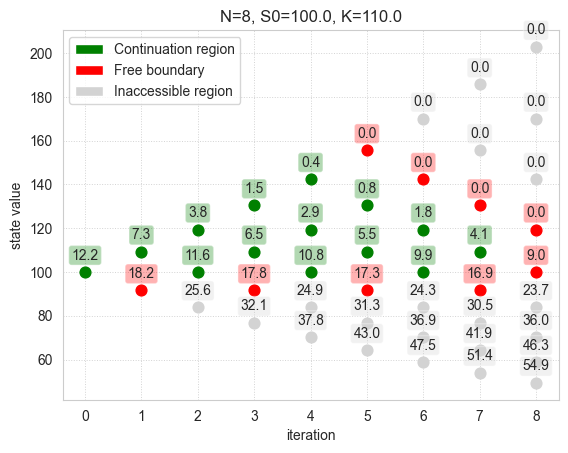

In [143]:
fig, ax = plt.subplots()
plot(ax, states)
ax.set_ylabel("state value")
ax.set_xlabel("iteration")
ax.set_title(f"N={N}, S0={S0}, K={K}")
plt.show()